Week 1 Tasks
**Task 1**: Environment Setup & Library Verification
This task verifies that required libraries are installed and working.

**Task 2**: Dataset Preview
Each row represents a student's record.
Each column represents attributes such as gender, race, parental education, lunch type, test preparation, and scores.

**Step 3: Dataset Structure Analysis**

This step analyzes the structure of the dataset by examining its shape, data types, and column information.

Each row represents a student record, and each column represents a feature such as gender, parental education, lunch type, and exam scores.

In [5]:


import pandas as pd

df = pd.read_csv("../data/StudentsPerformance.csv")

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print("Rows and Columns:", df.shape)

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

# Count categorical and numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 60)
print("COLUMN TYPE COUNT")
print("=" * 60)
print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

print("\nCategorical Columns Names:")
print(categorical_cols)

print("\nNumerical Columns Names:")
print(numerical_cols)

DATASET SHAPE
Rows and Columns: (1000, 8)
DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
DATA TYPES
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading sco

C:\Users\Ijaz\AppData\Local\Temp\ipykernel_17088\3090378236.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


### Analysis

The dataset contains both categorical and numerical variables. The categorical columns include gender, race/ethnicity, parental level of education, lunch type, and test preparation course. These are stored as object data types.

The numerical columns include math score, reading score, and writing score, which are correctly stored as integer values.

The data types are appropriate for analysis. However, for machine learning models, categorical variables would need to be converted into numerical form using encoding techniques such as label encoding or one-hot encoding.

Overall, the dataset structure is well-organized and suitable for further analysis.

**Step 4: Missing Value and Duplicate Analysis**

This step checks whether the dataset contains missing values or duplicate records. Missing values are counted for each column, and the percentage of missing values is calculated. A bar chart is also created to visually verify missing values per column.

MISSING VALUES COUNT
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
total_score                    0
average_score                  0
performance_grade              0
high_achiever                  0
lowest_subject                 0
dtype: int64
MISSING VALUES PERCENTAGE
gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
total_score                    0.0
average_score                  0.0
performance_grade              0.0
high_achiever                  0.0
lowest_subject                 0.0
dtype: float64
DUPLICATE ROWS COUNT
0


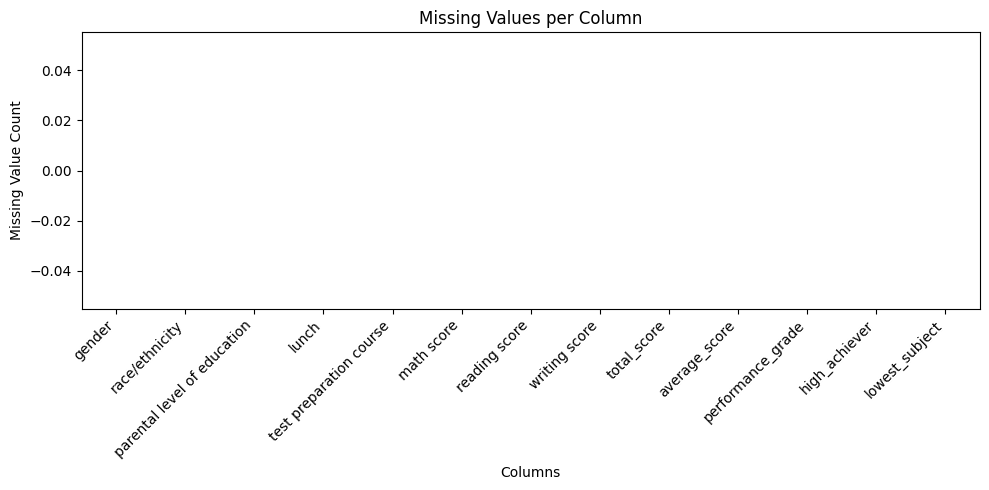

In [19]:
import matplotlib.pyplot as plt

print("=" * 60)
print("MISSING VALUES COUNT")
print("=" * 60)

missing_values = df.isnull().sum()
print(missing_values)

print("=" * 60)
print("MISSING VALUES PERCENTAGE")
print("=" * 60)

missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage)

print("=" * 60)
print("DUPLICATE ROWS COUNT")
print("=" * 60)

duplicate_count = df.duplicated().sum()
print(duplicate_count)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary.to_csv("../output/missing_values_summary.csv")

plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Value Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../output/missing_values_chart.png")
plt.show()

**Analysis**

The dataset appears to be clean because there are no missing values in the columns. The duplicate count is also checked to ensure that repeated records are not present.

If missing values were present, numerical columns could be filled using mean or median values depending on the distribution. Categorical columns could be filled using the mode or a separate category such as "Unknown".

If a column had too many missing values, I would investigate the reason first before removing it. Overall, this step helps verify that the dataset is reliable for further analysis.

**Step 5: Descriptive Statistics**

This step calculates complete descriptive statistics for the dataset and then separately analyzes the three score columns: math score, reading score, and writing score.

The calculated measures include mean, median, mode, standard deviation, variance, minimum, maximum, and range.

In [20]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe())

score_columns = ["math score", "reading score", "writing score"]

summary_list = []

for col in score_columns:
    summary_list.append({
        "Subject": col,
        "Mean": df[col].mean(),
        "Median": df[col].median(),
        "Mode": df[col].mode()[0],
        "Standard Deviation": df[col].std(),
        "Variance": df[col].var(),
        "Minimum": df[col].min(),
        "Maximum": df[col].max(),
        "Range": df[col].max() - df[col].min()
    })

summary_df = pd.DataFrame(summary_list)

print("=" * 60)
print("SUBJECT-WISE SUMMARY STATISTICS")
print("=" * 60)

display(summary_df)

summary_df.to_csv("../output/summary_statistics.csv", index=False)

highest_average = summary_df.loc[summary_df["Mean"].idxmax(), "Subject"]
highest_variability = summary_df.loc[summary_df["Standard Deviation"].idxmax(), "Subject"]

print("Subject with highest average:", highest_average)
print("Subject with highest variability:", highest_variability)

DESCRIPTIVE STATISTICS


,math score,reading score,writing score,total_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


SUBJECT-WISE SUMMARY STATISTICS


,Subject,Mean,Median,Mode,Standard Deviation,Variance,Minimum,Maximum,Range
0,math score,66.089,66.0,65,15.163080,229.918998,0,100,100
1,reading score,69.169,70.0,72,14.600192,213.165605,17,100,83
2,writing score,68.054,69.0,74,15.195657,230.907992,10,100,90


Subject with highest average: reading score
Subject with highest variability: writing score


**Analysis**

The subject with the highest average score can be identified by comparing the mean values in the summary table. This shows which subject students performed best in overall.

The subject with the highest standard deviation has the highest variability. This means student performance in that subject is less consistent compared to the other subjects.

If a subject has a high average and low variability, it may indicate that most students performed consistently well in that subject. If a subject has high variability, it may suggest that some students found it difficult while others performed well.

**Step 6: Categorical Distribution Analysis**

This step analyzes all categorical columns using counts and percentages. Bar charts are created to understand the distribution of gender, race/ethnicity, parental education, lunch type, and test preparation course.

VALUE COUNTS FOR: gender
gender
female    518
male      482
Name: count, dtype: int64

Percentage:
gender
female    51.8
male      48.2
Name: proportion, dtype: float64
VALUE COUNTS FOR: race/ethnicity


race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentage:
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64
VALUE COUNTS FOR: parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentage:
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64
VALUE COUNTS FOR: lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Percentage:
lunch
standard        64.5
free/reduced    35.5
Name: proportion, dtype: float64
VALUE COUNTS FOR: test preparation course
test preparation co

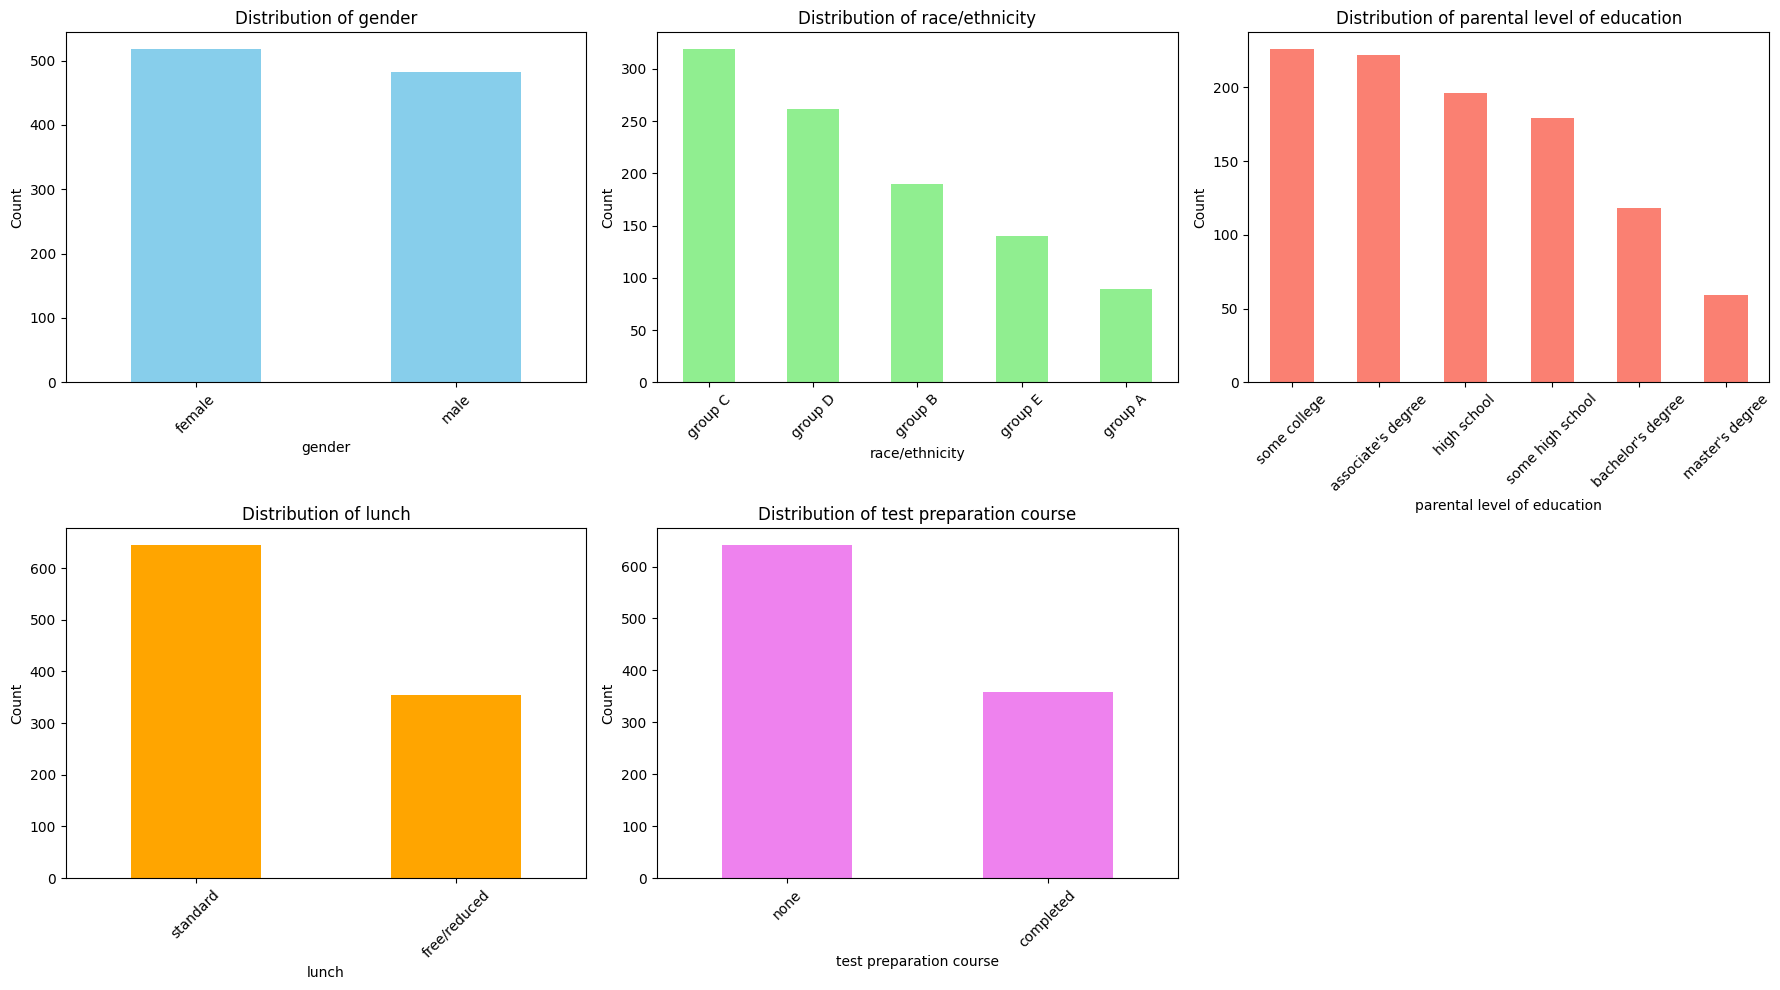

STEP 6 ANALYSIS VALUES
Test preparation percentage:
test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64

Most common parental education level: some college


In [21]:
import matplotlib.pyplot as plt

categorical_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_cols:
    print("=" * 60)
    print(f"VALUE COUNTS FOR: {col}")
    print("=" * 60)
    print(df[col].value_counts())

    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ["skyblue", "lightgreen", "salmon", "orange", "violet"]

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color=colors[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

axes[5].axis("off")

plt.tight_layout()
plt.savefig("../output/categorical_distribution.png")
plt.show()

test_prep_fraction = df["test preparation course"].value_counts(normalize=True) * 100
most_common_parent_edu = df["parental level of education"].value_counts().idxmax()

print("=" * 60)
print("STEP 6 ANALYSIS VALUES")
print("=" * 60)
print("Test preparation percentage:")
print(test_prep_fraction)

print("\nMost common parental education level:", most_common_parent_edu)

**Analysis**

The test preparation course column shows the percentage of students who completed the course and those who did not. The completed percentage represents the fraction of students who participated in test preparation.

The most common parental education level can be identified from the highest value count in the parental level of education column.

This distribution analysis helps understand the background of students before comparing their academic performance.

 **Step 7: Group Mean Score Comparisons**

This step compares average math, reading, and writing scores across important categorical groups using `groupby()`. It helps identify whether background factors such as gender, parental education, lunch type, and test preparation are associated with score differences.

MEAN SCORES GROUPED BY: gender


,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


MEAN SCORES GROUPED BY: race/ethnicity


,math score,reading score,writing score
race/ethnicity,,,
group A,61.63,64.67,62.67
group B,63.45,67.35,65.60
group C,64.46,69.10,67.83
group D,67.36,70.03,70.15
group E,73.82,73.03,71.41


MEAN SCORES GROUPED BY: parental level of education


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


MEAN SCORES GROUPED BY: lunch


,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


MEAN SCORES GROUPED BY: test preparation course


,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


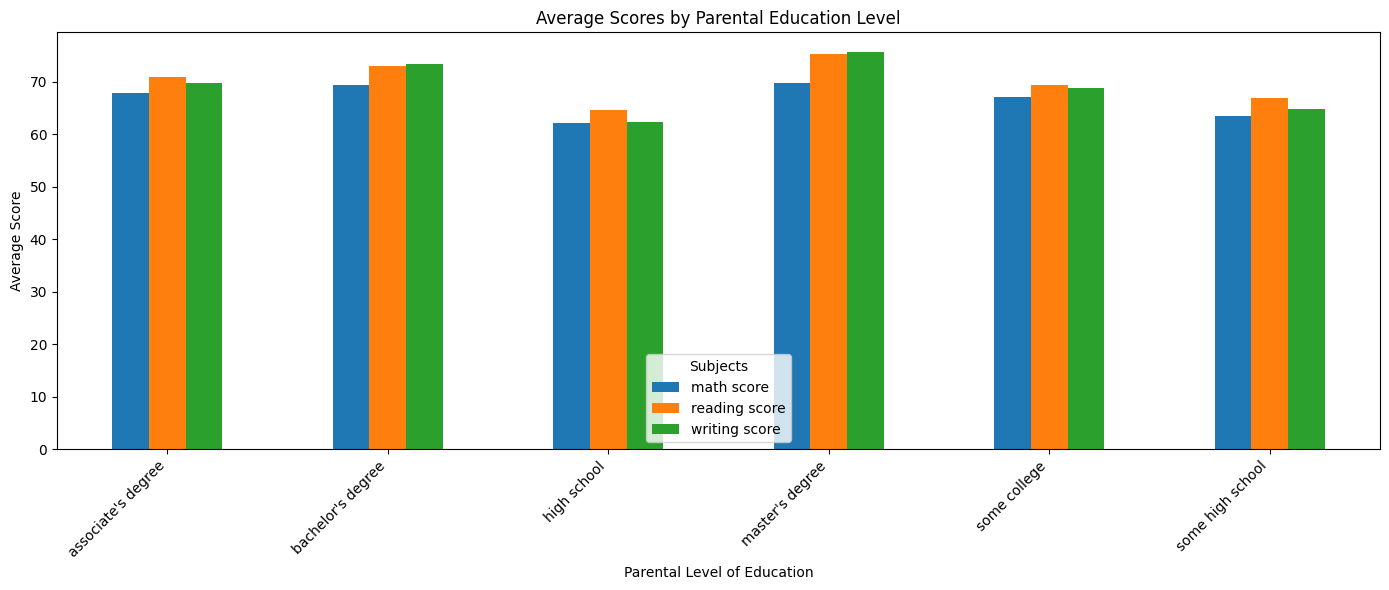

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


In [22]:
score_cols = ["math score", "reading score", "writing score"]

group_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in group_columns:
    print("=" * 60)
    print(f"MEAN SCORES GROUPED BY: {col}")
    print("=" * 60)

    grouped_mean = df.groupby(col)[score_cols].mean().round(2)
    display(grouped_mean)

parent_edu_scores = df.groupby("parental level of education")[score_cols].mean().round(2)

parent_edu_scores.plot(kind="bar", figsize=(14, 6))

plt.title("Average Scores by Parental Education Level")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Subjects")
plt.tight_layout()

plt.savefig("../output/parental_education_scores.png")
plt.show()

display(parent_edu_scores)

**Analysis**

Parental education appears to have an impact on student scores. Students whose parents have higher education levels generally show stronger average performance compared to students whose parents have lower education levels.

For example, students whose parents have a master's degree or bachelor's degree usually show higher average scores across math, reading, and writing compared to some lower education categories.

The exact impact should be explained using the values shown in the grouped table. If the difference between categories is several marks, it suggests that parental education may influence academic performance through home support, learning environment, or educational awareness.

**Step 8: Correlation Analysis and Heatmap**

This step analyzes the relationship between math, reading, and writing scores using correlation. A heatmap is used to visually show how strongly the score columns are related.

CORRELATION MATRIX


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


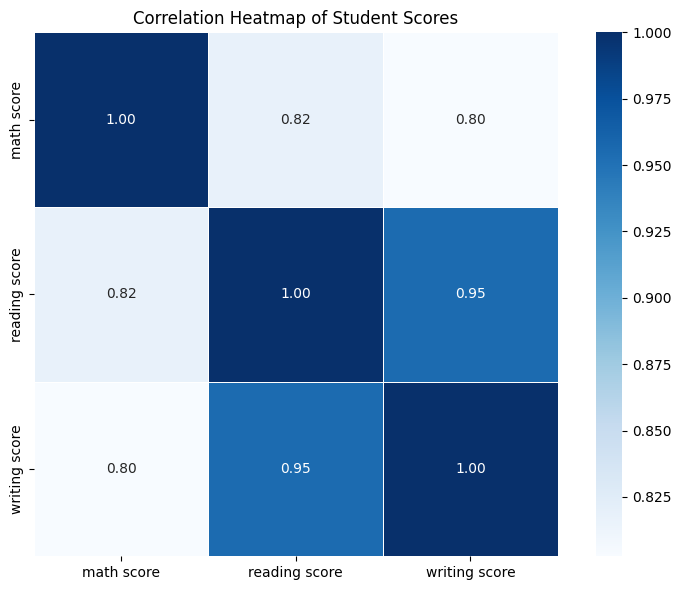

PEARSON CORRELATIONS
Math vs Reading: 0.82
Reading vs Writing: 0.95
Math vs Writing: 0.8


In [23]:
import seaborn as sns

score_cols = ["math score", "reading score", "writing score"]

correlation_matrix = df[score_cols].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Scores")
plt.tight_layout()
plt.savefig("../output/score_correlation_heatmap.png")
plt.show()

math_reading_corr = df["math score"].corr(df["reading score"])
reading_writing_corr = df["reading score"].corr(df["writing score"])
math_writing_corr = df["math score"].corr(df["writing score"])

print("=" * 60)
print("PEARSON CORRELATIONS")
print("=" * 60)
print("Math vs Reading:", round(math_reading_corr, 2))
print("Reading vs Writing:", round(reading_writing_corr, 2))
print("Math vs Writing:", round(math_writing_corr, 2))

**Analysis**

The correlation matrix shows the strength of relationships between math, reading, and writing scores. The pair with the highest correlation is the most strongly related.

Usually, reading and writing scores are highly correlated because both subjects depend on language comprehension, vocabulary, and written expression skills.

A strong positive correlation means that students who perform well in one subject also tend to perform well in the other. Educationally, this suggests that improving reading skills may also support writing performance.

Math also has a positive relationship with reading and writing, but the relationship may be slightly weaker because math depends more on numerical reasoning and problem-solving skills.

**Step 9: Test Preparation Impact Analysis**

This step compares students who completed the test preparation course with students who did not. Mean scores, standard deviation, box plots, and improvement percentages are used to measure the impact of test preparation.

TEST PREPARATION MEAN AND STANDARD DEVIATION


math score        reading score        writing score  \
                              mean    std          mean    std          mean   
test preparation course                                                        
completed                    69.70  14.44         73.89  13.64         74.42   
none                         64.08  15.19         66.53  14.46         64.50   

                                
                           std  
test preparation course         
completed                13.38  
none                     15.00

IMPROVEMENT PERCENTAGE


,Subject,Completed Mean,None Mean,Improvement Percentage
0,math score,69.70,64.08,8.77
1,reading score,73.89,66.53,11.06
2,writing score,74.42,64.50,15.37


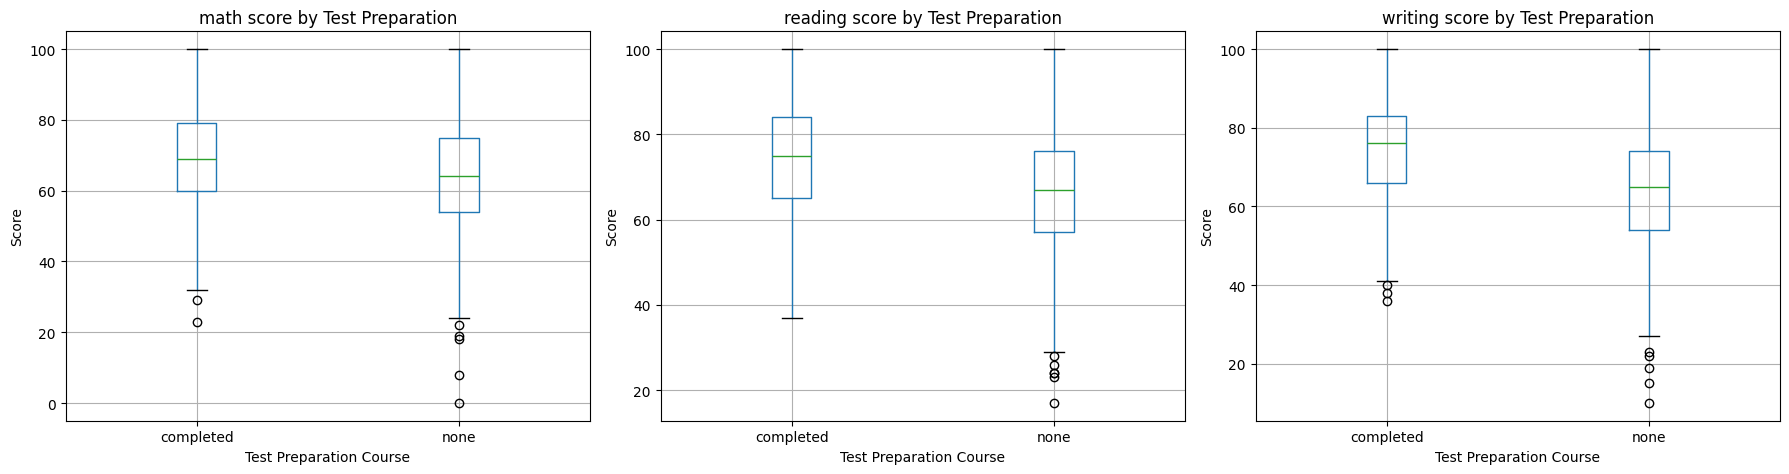

In [24]:
score_cols = ["math score", "reading score", "writing score"]

test_prep_stats = df.groupby("test preparation course")[score_cols].agg(["mean", "std"]).round(2)

print("=" * 60)
print("TEST PREPARATION MEAN AND STANDARD DEVIATION")
print("=" * 60)
display(test_prep_stats)

completed_mean = df[df["test preparation course"] == "completed"][score_cols].mean()
none_mean = df[df["test preparation course"] == "none"][score_cols].mean()

improvement_percentage = ((completed_mean - none_mean) / none_mean) * 100

improvement_df = pd.DataFrame({
    "Subject": score_cols,
    "Completed Mean": completed_mean.values,
    "None Mean": none_mean.values,
    "Improvement Percentage": improvement_percentage.values
}).round(2)

print("=" * 60)
print("IMPROVEMENT PERCENTAGE")
print("=" * 60)
display(improvement_df)

improvement_df.to_csv("../output/test_prep_improvement.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(score_cols):
    df.boxplot(column=col, by="test preparation course", ax=axes[i])
    axes[i].set_title(f"{col} by Test Preparation")
    axes[i].set_xlabel("Test Preparation Course")
    axes[i].set_ylabel("Score")

plt.suptitle("")
plt.tight_layout()
plt.savefig("../output/test_prep_boxplots.png")
plt.show()

**Analysis**

The improvement percentage table shows which subject benefits the most from test preparation. The subject with the highest improvement percentage is the one where completed students gained the largest relative advantage over students who did not complete the course.

If all three subjects show better average scores for students who completed test preparation, then the program appears useful.

Based on this analysis, I would recommend the test preparation program if it consistently improves average performance across subjects. However, the final recommendation should also consider cost, student participation, and whether the improvement is large enough to be practically meaningful.

**Step 10: Gender Score Deep-Dive**

This step compares male and female student performance using overlapping histograms for math, reading, and writing scores. It also calculates the percentage of male and female students scoring above 70 in each subject.

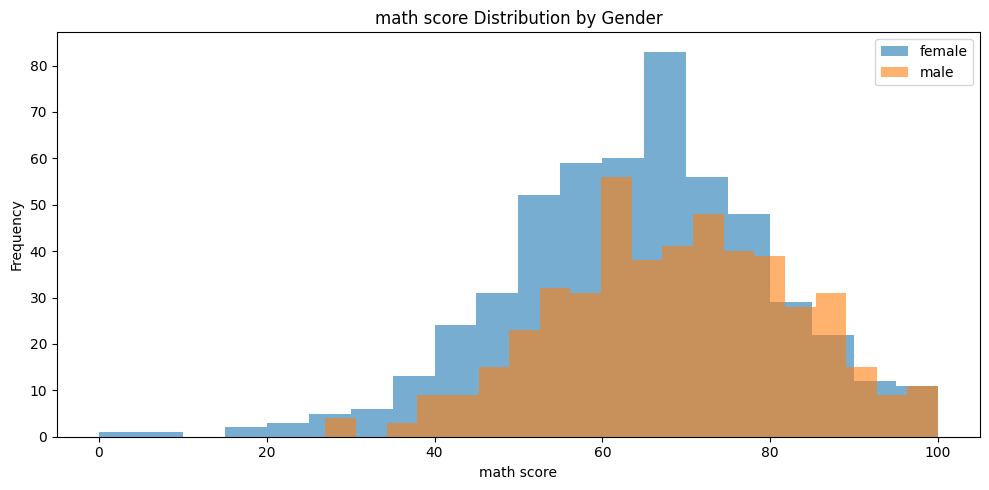

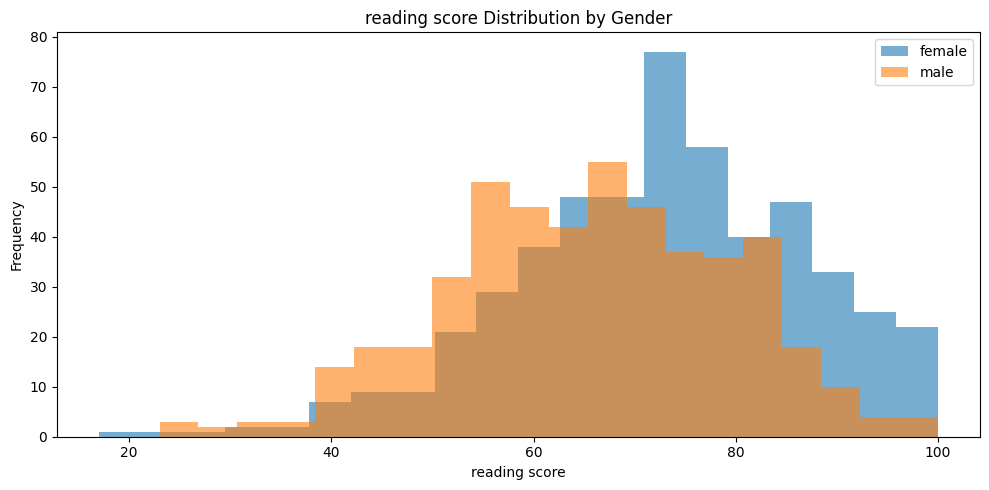

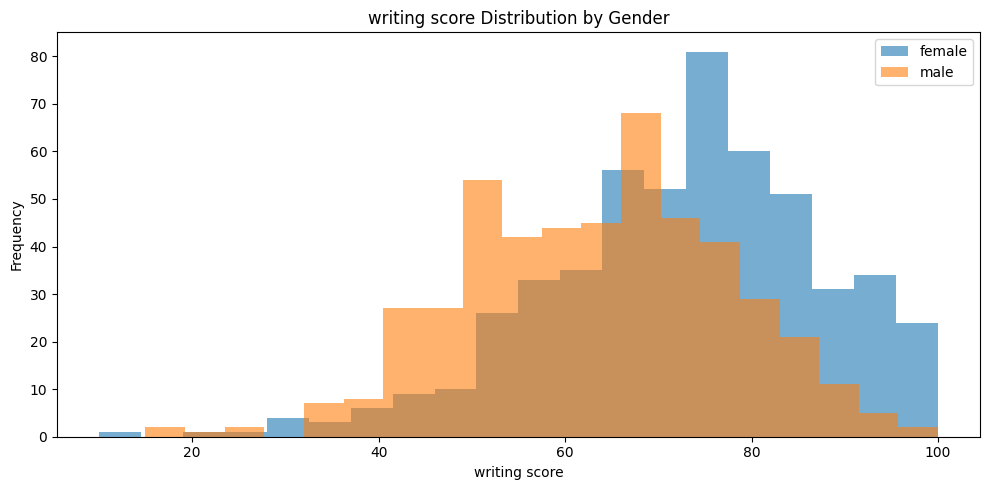

PERCENTAGE OF STUDENTS SCORING ABOVE 70 BY GENDER


,Subject,Gender,Percentage Above 70
0,math score,female,32.82
1,math score,male,45.85
2,reading score,female,58.30
3,reading score,male,38.38
4,writing score,female,58.11
5,writing score,male,32.16


In [25]:
score_cols = ["math score", "reading score", "writing score"]

for col in score_cols:
    plt.figure(figsize=(10, 5))

    for gender in df["gender"].unique():
        plt.hist(
            df[df["gender"] == gender][col],
            alpha=0.6,
            label=gender,
            bins=20
        )

    plt.title(f"{col} Distribution by Gender")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../output/{col.replace(' ', '_')}_gender_histogram.png")
    plt.show()

summary_percentages = []

for subject in score_cols:
    for gender in df["gender"].unique():
        total_students = len(df[df["gender"] == gender])
        above_70 = len(df[(df["gender"] == gender) & (df[subject] > 70)])
        percentage = (above_70 / total_students) * 100

        summary_percentages.append({
            "Subject": subject,
            "Gender": gender,
            "Percentage Above 70": round(percentage, 2)
        })

gender_summary_df = pd.DataFrame(summary_percentages)

print("=" * 60)
print("PERCENTAGE OF STUDENTS SCORING ABOVE 70 BY GENDER")
print("=" * 60)
display(gender_summary_df)

gender_summary_df.to_csv("../output/gender_above_70_summary.csv", index=False)

**Analysis**

The percentage summary table shows whether male or female students have a higher percentage of scores above 70 in each subject.

Females often outperform males in reading and writing, while males may perform slightly better in math depending on the dataset values.

If the percentage differences are small, the gender gap is not very large. If the difference is more than a few percentage points, it may suggest a noticeable performance gap.

Possible factors may include learning habits, subject interest, preparation level, classroom support, and differences in reading or writing confidence. However, gender alone should not be treated as the only cause because academic performance is influenced by many social, educational, and personal factors.

**Step 11: Feature Engineering — 5 New Columns**

This step creates new useful features from existing score columns. These features help summarize student performance and make the dataset more useful for analysis and machine learning.

In [26]:
import numpy as np

# Create total score
df["total_score"] = df["math score"] + df["reading score"] + df["writing score"]

# Create average score
df["average_score"] = df["total_score"] / 3

# Create performance grade
def assign_grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    elif avg >= 50:
        return "D"
    else:
        return "F"

df["performance_grade"] = df["average_score"].apply(assign_grade)

# Create high achiever column
df["high_achiever"] = df["average_score"] >= 80

# Create lowest subject column
score_cols = ["math score", "reading score", "writing score"]
df["lowest_subject"] = df[score_cols].idxmin(axis=1)

print("=" * 60)
print("FIRST 10 ROWS WITH NEW FEATURE COLUMNS")
print("=" * 60)

display(df.head(10))

print("=" * 60)
print("PERFORMANCE GRADE COUNTS")
print("=" * 60)
print(df["performance_grade"].value_counts())

print("=" * 60)
print("LOWEST SUBJECT COUNTS")
print("=" * 60)
print(df["lowest_subject"].value_counts())

df.to_csv("../output/feature_engineered_dataset.csv", index=False)

FIRST 10 ROWS WITH NEW FEATURE COLUMNS


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,performance_grade,high_achiever,lowest_subject
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,B,False,math score
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,A,True,math score
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,A,True,math score
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,F,False,writing score
4,male,group C,some college,standard,none,76,78,75,229,76.333333,B,False,writing score
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333,B,False,math score
6,female,group B,some college,standard,completed,88,95,92,275,91.666667,A,True,math score
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667,F,False,writing score
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000,C,False,math score
9,female,group B,high school,free/reduced,none,38,60,50,148,49.333333,F,False,math score


PERFORMANCE GRADE COUNTS
performance_grade
B    261
C    256
A    198
D    182
F    103
Name: count, dtype: int64
LOWEST SUBJECT COUNTS
lowest_subject
math score       552
writing score    292
reading score    156
Name: count, dtype: int64


**Analysis**

The `total_score` column gives the combined performance of each student across math, reading, and writing. The `average_score` column provides a more balanced single performance measure.

The `performance_grade` column converts numerical average scores into grade categories, which makes interpretation easier. The `high_achiever` column identifies students with an average score of 80 or above.

The `lowest_subject` column helps identify the subject where each student needs the most improvement. These engineered features are useful for reporting, visualization, and future machine learning tasks.

**Step 12: Pair Plot Multi-Variable Analysis**

This step creates pair plots to visually analyze relationships between score columns and average score. The first pair plot uses gender as hue, and the second pair plot uses performance grade as hue.

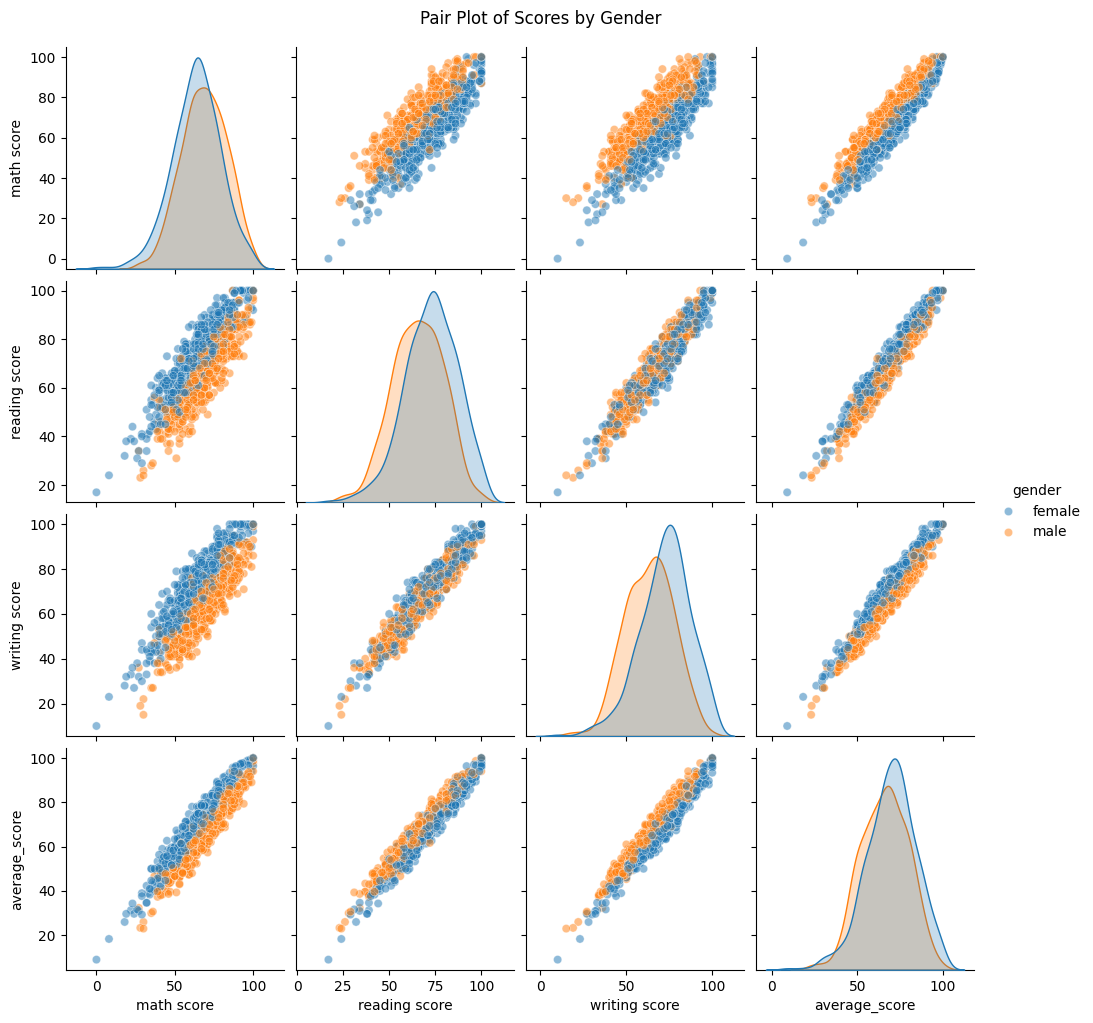

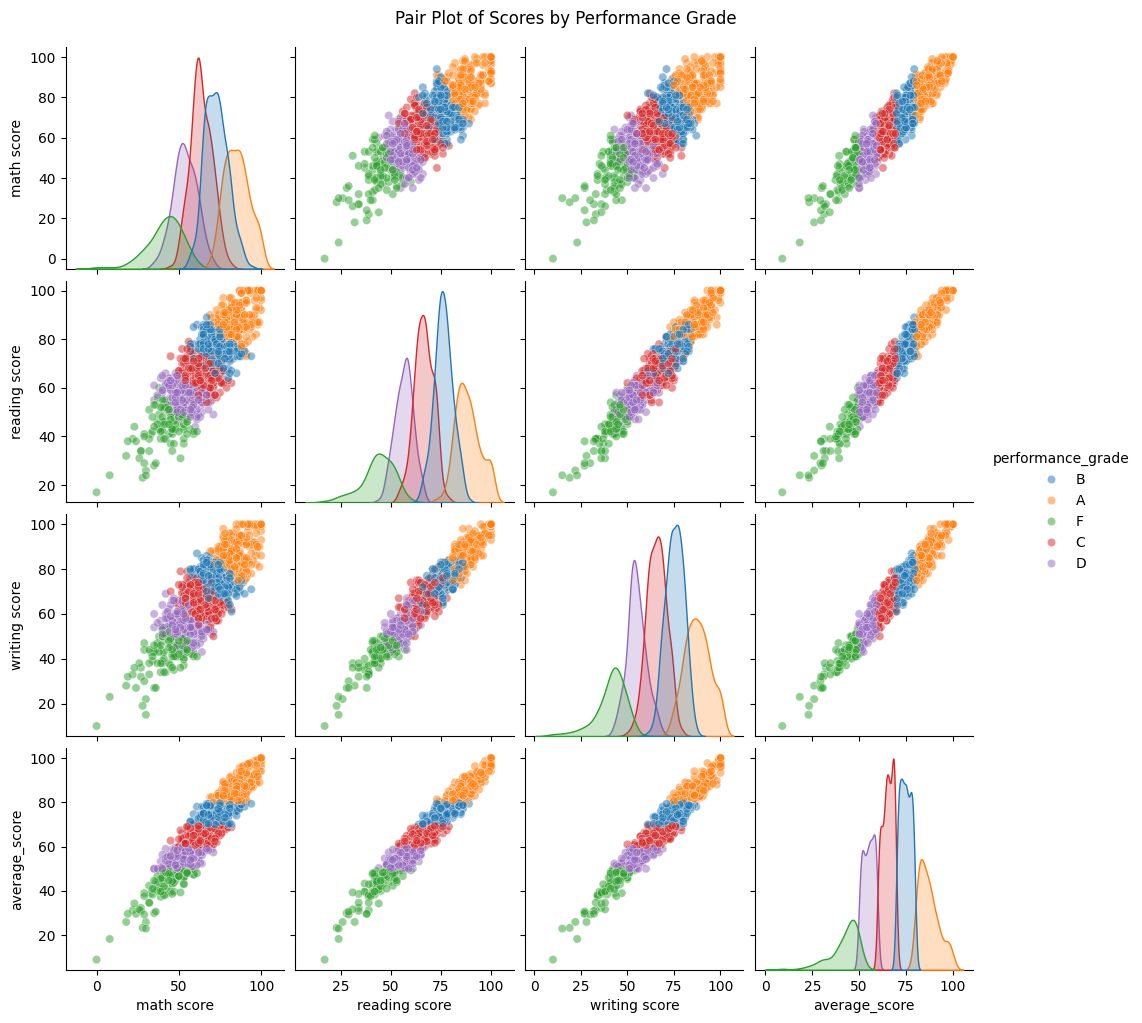

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_cols = ["math score", "reading score", "writing score", "average_score"]

# Pair plot by gender
pairplot_gender = sns.pairplot(
    df[pairplot_cols + ["gender"]],
    hue="gender",
    plot_kws=dict(alpha=0.5)
)

pairplot_gender.fig.suptitle("Pair Plot of Scores by Gender", y=1.02)
pairplot_gender.savefig("../output/pairplot_scores.png", dpi=150)
plt.show()

# Pair plot by performance grade
pairplot_grade = sns.pairplot(
    df[pairplot_cols + ["performance_grade"]],
    hue="performance_grade",
    plot_kws=dict(alpha=0.5)
)

pairplot_grade.fig.suptitle("Pair Plot of Scores by Performance Grade", y=1.02)
pairplot_grade.savefig("../output/pairplot_grades.png", dpi=150)
plt.show()

**Analysis**

The pair plot with gender shows that male and female students are not fully separable based only on score patterns. There is overlap between both gender groups across math, reading, writing, and average score.

The pair plot with performance grade shows clearer separation because grades are directly based on average score. Higher grades appear in higher score ranges, while lower grades appear in lower score ranges.

This means a classifier would likely perform better when predicting performance grade from score columns compared to predicting gender from scores. Gender is not strongly separable using only academic score variables, while performance grade is naturally connected to the score features.

**Step 13: Pivot Tables and Advanced Grouping**

This step creates pivot tables to compare average scores across multiple categorical variables. Heatmaps are used to make group differences easier to understand visually.

PIVOT TABLE: PARENTAL EDUCATION VS GENDER


gender,female,male
parental level of education,,
associate's degree,71.12,67.87
bachelor's degree,74.67,68.78
high school,64.75,61.58
master's degree,73.65,73.52
some college,71.00,65.72
some high school,65.56,64.64


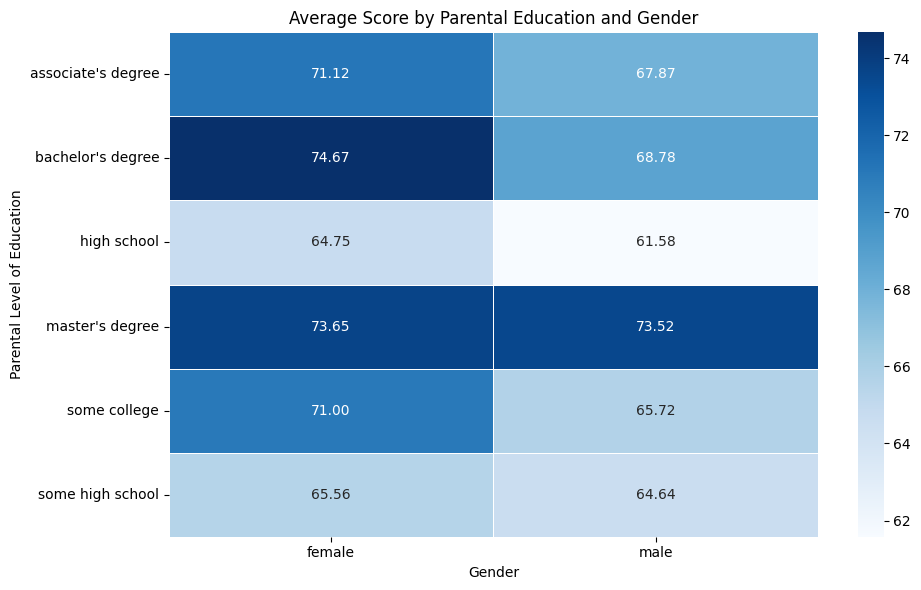

PIVOT TABLE: RACE/ETHNICITY VS TEST PREPARATION


test preparation course,completed,none
race/ethnicity,,
group A,68.26,58.09
group B,67.19,61.37
group C,67.50,62.71
group D,69.79,66.26
group E,77.43,71.11


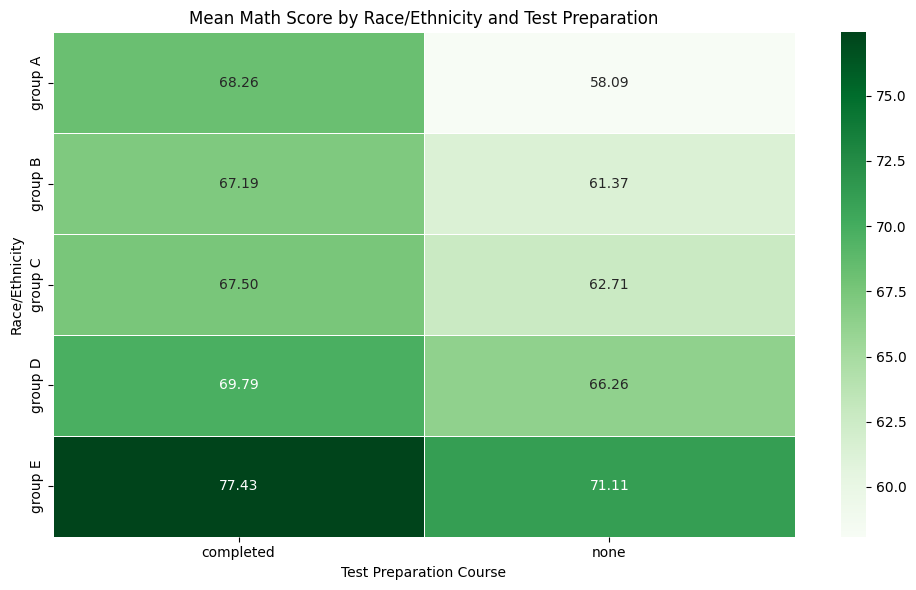

In [28]:
# Pivot 1: parental education vs gender using average score
pivot_parent_gender = pd.pivot_table(
    df,
    values="average_score",
    index="parental level of education",
    columns="gender",
    aggfunc="mean"
).round(2)

print("=" * 60)
print("PIVOT TABLE: PARENTAL EDUCATION VS GENDER")
print("=" * 60)
display(pivot_parent_gender)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_parent_gender,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Average Score by Parental Education and Gender")
plt.xlabel("Gender")
plt.ylabel("Parental Level of Education")
plt.tight_layout()
plt.savefig("../output/parent_gender_average_score_heatmap.png")
plt.show()


# Pivot 2: race/ethnicity vs test preparation using math score
pivot_race_testprep = pd.pivot_table(
    df,
    values="math score",
    index="race/ethnicity",
    columns="test preparation course",
    aggfunc="mean"
).round(2)

print("=" * 60)
print("PIVOT TABLE: RACE/ETHNICITY VS TEST PREPARATION")
print("=" * 60)
display(pivot_race_testprep)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_race_testprep,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title("Mean Math Score by Race/Ethnicity and Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Race/Ethnicity")
plt.tight_layout()
plt.savefig("../output/race_testprep_math_heatmap.png")
plt.show()

# Save pivot tables
pivot_parent_gender.to_csv("../output/pivot_parent_gender.csv")
pivot_race_testprep.to_csv("../output/pivot_race_testprep.csv")

**Analysis**

The pivot table shows that the gender gap can change across parental education levels. In some parental education groups, female students may have higher average scores, while in other groups the difference may be smaller.

This means gender-based performance differences are not exactly the same across all parental education categories. Parental education may interact with gender by influencing academic support, learning habits, and access to educational resources.

The heatmap makes it easier to identify where the largest differences appear. If one gender consistently has higher scores across most education groups, that suggests a repeated pattern. If the gap changes from one group to another, then the relationship is more complex and should not be explained by gender alone.

**Step 14: Reusable Python Functions**

This step creates three reusable Python functions from scratch. These functions help summarize scores, visualize distributions, and compare group performance.

In [29]:
def score_summary(df, col):
    """
    Returns a summary dictionary for a selected score column.

    Parameters:
    df: pandas DataFrame
    col: column name to analyze

    Returns:
    dict: mean, median, standard deviation, minimum, maximum, and percentage above 70
    """
    summary = {
        "Column": col,
        "Mean": round(df[col].mean(), 2),
        "Median": round(df[col].median(), 2),
        "Std": round(df[col].std(), 2),
        "Min": df[col].min(),
        "Max": df[col].max(),
        "Pct Above 70": round((df[col] > 70).mean() * 100, 2)
    }

    return summary


def plot_distribution(df, col, color):
    """
    Plots a histogram for a selected score column with KDE curve and mean line.

    Parameters:
    df: pandas DataFrame
    col: column name to visualize
    color: chart color
    """
    mean_value = df[col].mean()

    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, color=color, bins=20)

    plt.axvline(mean_value, color="red", linestyle="--", label=f"Mean = {mean_value:.2f}")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"../output/{col.replace(' ', '_')}_distribution.png")
    plt.show()


def compare_groups(df, group_col, score_col):
    """
    Compares mean score and percentage above 70 across groups.

    Parameters:
    df: pandas DataFrame
    group_col: categorical column used for grouping
    score_col: score column to analyze

    Returns:
    pandas DataFrame: sorted group mean scores and percentage above 70
    """
    result = df.groupby(group_col).apply(
        lambda x: pd.Series({
            "Mean Score": round(x[score_col].mean(), 2),
            "Pct Above 70": round((x[score_col] > 70).mean() * 100, 2)
        })
    ).reset_index()

    result = result.sort_values(by="Mean Score", ascending=False)

    return result

FUNCTION 1: SCORE SUMMARY


,Column,Mean,Median,Std,Min,Max,Pct Above 70
0,math score,66.09,66.0,15.16,0,100,39.1
1,reading score,69.17,70.0,14.60,17,100,48.7
2,writing score,68.05,69.0,15.20,10,100,45.6


FUNCTION 2: PLOT DISTRIBUTION


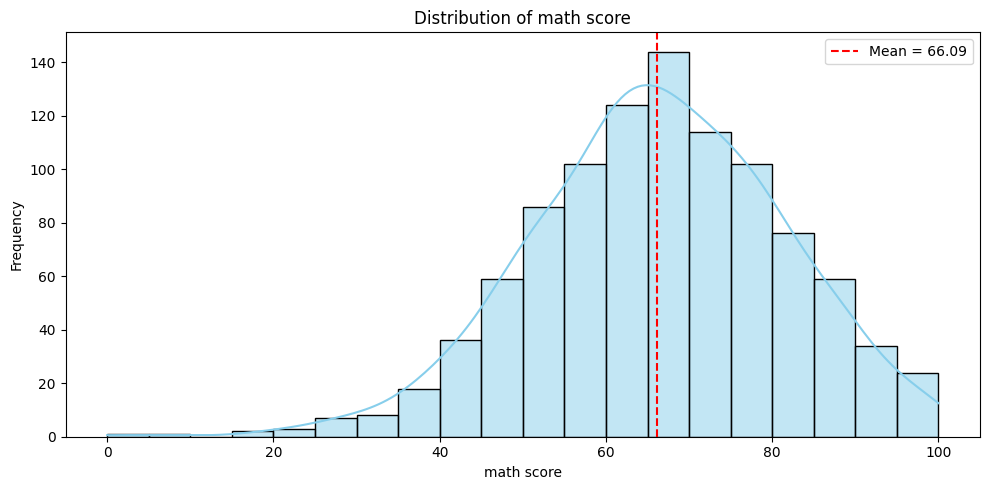

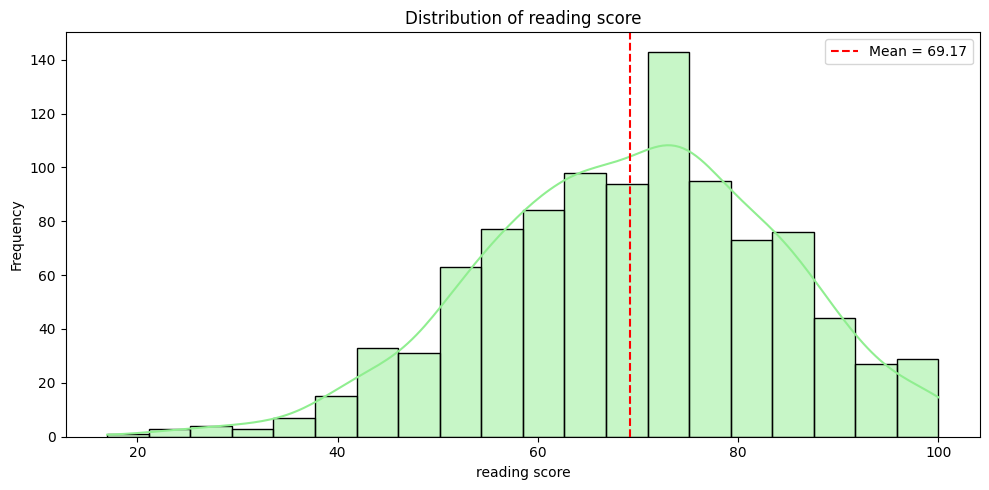

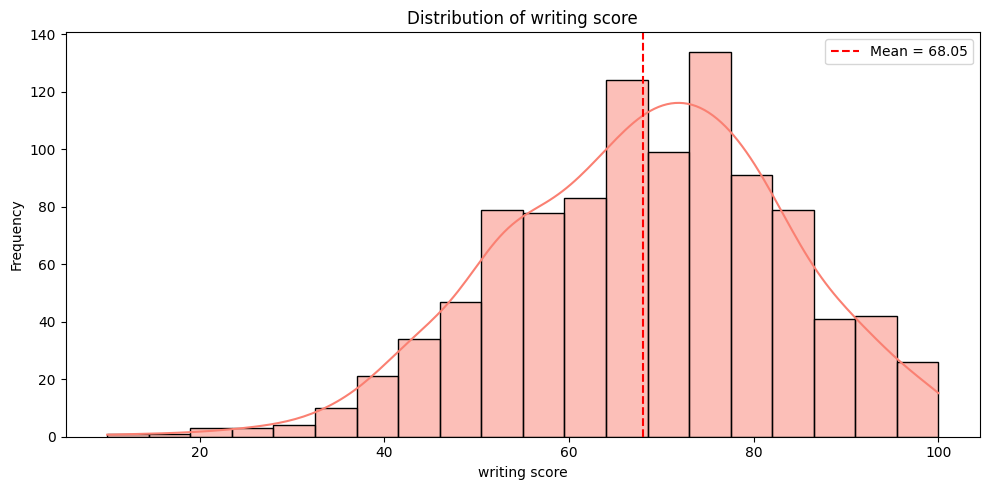

FUNCTION 3: COMPARE GROUPS
Gender vs Math Score


,gender,Mean Score,Pct Above 70
1,male,68.73,45.85
0,female,63.63,32.82


Test Preparation vs Reading Score


,test preparation course,Mean Score,Pct Above 70
0,completed,73.89,62.57
1,none,66.53,40.97


Lunch Type vs Writing Score


,lunch,Mean Score,Pct Above 70
1,standard,70.82,52.71
0,free/reduced,63.02,32.68


In [30]:
print("=" * 60)
print("FUNCTION 1: SCORE SUMMARY")
print("=" * 60)

math_summary = score_summary(df, "math score")
reading_summary = score_summary(df, "reading score")
writing_summary = score_summary(df, "writing score")

summary_function_df = pd.DataFrame([
    math_summary,
    reading_summary,
    writing_summary
])

display(summary_function_df)

summary_function_df.to_csv("../output/function_score_summary.csv", index=False)


print("=" * 60)
print("FUNCTION 2: PLOT DISTRIBUTION")
print("=" * 60)

plot_distribution(df, "math score", "skyblue")
plot_distribution(df, "reading score", "lightgreen")
plot_distribution(df, "writing score", "salmon")


print("=" * 60)
print("FUNCTION 3: COMPARE GROUPS")
print("=" * 60)

gender_math_comparison = compare_groups(df, "gender", "math score")
test_prep_reading_comparison = compare_groups(df, "test preparation course", "reading score")
lunch_writing_comparison = compare_groups(df, "lunch", "writing score")

print("Gender vs Math Score")
display(gender_math_comparison)

print("Test Preparation vs Reading Score")
display(test_prep_reading_comparison)

print("Lunch Type vs Writing Score")
display(lunch_writing_comparison)

gender_math_comparison.to_csv("../output/function_gender_math_comparison.csv", index=False)
test_prep_reading_comparison.to_csv("../output/function_testprep_reading_comparison.csv", index=False)
lunch_writing_comparison.to_csv("../output/function_lunch_writing_comparison.csv", index=False)


**Analysis**

The `score_summary()` function is useful because it quickly returns important statistics for any score column. It includes average performance, spread, score range, and the percentage of students scoring above 70.

The `plot_distribution()` function helps visualize score distribution with a histogram, KDE curve, and mean line. This makes it easier to understand whether scores are centered, spread out, or skewed.

The `compare_groups()` function helps compare student performance across categorical groups such as gender, lunch type, or test preparation course. It returns both mean score and percentage above 70, which gives a clearer view of group-level performance.

**Step 15: NumPy Manual Statistical Computations**

This step performs statistical calculations using NumPy only. The purpose is to manually verify descriptive statistics, z-scores, percentiles, sorting, and pass rates without relying on Pandas statistical methods.

In [31]:
import numpy as np
import pandas as pd

# Extract score arrays using NumPy values
math_arr = df["math score"].values
reading_arr = df["reading score"].values
writing_arr = df["writing score"].values

score_arrays = {
    "math score": math_arr,
    "reading score": reading_arr,
    "writing score": writing_arr
}

# Part A: NumPy statistics
numpy_stats = []

for subject, arr in score_arrays.items():
    numpy_stats.append({
        "Subject": subject,
        "Mean": np.mean(arr),
        "Median": np.median(arr),
        "Std": np.std(arr),
        "Variance": np.var(arr),
        "Min": np.min(arr),
        "Max": np.max(arr)
    })

numpy_stats_df = pd.DataFrame(numpy_stats).round(2)

print("=" * 60)
print("NUMPY STATISTICAL COMPUTATIONS")
print("=" * 60)
display(numpy_stats_df)

# Part B: Z-score outlier counts
zscore_results = []

for subject, arr in score_arrays.items():
    z_scores = (arr - np.mean(arr)) / np.std(arr)

    zscore_results.append({
        "Subject": subject,
        "Z > +2 Count": np.sum(z_scores > 2),
        "Z < -2 Count": np.sum(z_scores < -2)
    })

zscore_df = pd.DataFrame(zscore_results)

print("=" * 60)
print("Z-SCORE OUTLIER COUNTS")
print("=" * 60)
display(zscore_df)

# Part C: Percentiles
percentile_values = [10, 25, 50, 75, 90]
percentile_results = []

for subject, arr in score_arrays.items():
    percentiles = np.percentile(arr, percentile_values)

    percentile_results.append({
        "Subject": subject,
        "10th": percentiles[0],
        "25th": percentiles[1],
        "50th": percentiles[2],
        "75th": percentiles[3],
        "90th": percentiles[4]
    })

percentile_df = pd.DataFrame(percentile_results).round(2)

print("=" * 60)
print("PERCENTILE TABLE")
print("=" * 60)
display(percentile_df)

# Part D: Top 10 math scorers by index
top_10_math_indices = np.argsort(math_arr)[-10:][::-1]

print("=" * 60)
print("TOP 10 MATH SCORERS BY INDEX")
print("=" * 60)
print(top_10_math_indices)

print("\nTop 10 Math Scores:")
print(math_arr[top_10_math_indices])

# Part E: Binary pass/fail array score > 70
pass_rate_results = []

for subject, arr in score_arrays.items():
    pass_array = np.where(arr > 70, 1, 0)
    pass_rate = np.mean(pass_array) * 100

    pass_rate_results.append({
        "Subject": subject,
        "Pass Rate Above 70 (%)": pass_rate
    })

pass_rate_df = pd.DataFrame(pass_rate_results).round(2)

print("=" * 60)
print("PASS RATE ABOVE 70")
print("=" * 60)
display(pass_rate_df)

# Save all outputs
numpy_stats_df.to_csv("../output/numpy_statistics.csv", index=False)
zscore_df.to_csv("../output/zscore_outliers.csv", index=False)
percentile_df.to_csv("../output/percentile_table.csv", index=False)
pass_rate_df.to_csv("../output/pass_rate_above_70.csv", index=False)

NUMPY STATISTICAL COMPUTATIONS


,Subject,Mean,Median,Std,Variance,Min,Max
0,math score,66.09,66.0,15.16,229.69,0,100
1,reading score,69.17,70.0,14.59,212.95,17,100
2,writing score,68.05,69.0,15.19,230.68,10,100


Z-SCORE OUTLIER COUNTS


,Subject,Z > +2 Count,Z < -2 Count
0,math score,19,27
1,reading score,20,26
2,writing score,18,24


PERCENTILE TABLE


,Subject,10th,25th,50th,75th,90th
0,math score,47.0,57.00,66.0,77.0,86.0
1,reading score,51.0,59.00,70.0,79.0,87.1
2,writing score,48.0,57.75,69.0,79.0,87.0


TOP 10 MATH SCORERS BY INDEX
[916 458 962 625 623 451 149 306 114 263]

Top 10 Math Scores:
[100 100 100 100 100 100 100  99  99  99]
PASS RATE ABOVE 70


,Subject,Pass Rate Above 70 (%)
0,math score,39.1
1,reading score,48.7
2,writing score,45.6


**Analysis**

The NumPy statistics confirm the central tendency and spread of the three score columns. Mean and median values help show typical student performance, while standard deviation and variance show how spread out the scores are.

The z-score analysis identifies students who are unusually high or unusually low compared to the class average. Students with z-scores greater than +2 are very high performers, while students below -2 are much lower than average.

The percentile table shows score distribution at different points, such as the 25th percentile, median, and 90th percentile. This helps understand how scores are spread across lower, middle, and higher-performing students.

The top 10 math scorer indices identify the strongest math performers by row index. The pass rate arrays show what percentage of students scored above 70 in each subject.

**Step 16: Professional 6-Chart EDA Dashboard**

This step creates a professional dashboard using six different charts to summarize student performance. These charts help visualize distributions, comparisons, relationships, and group-based insights in a single figure.

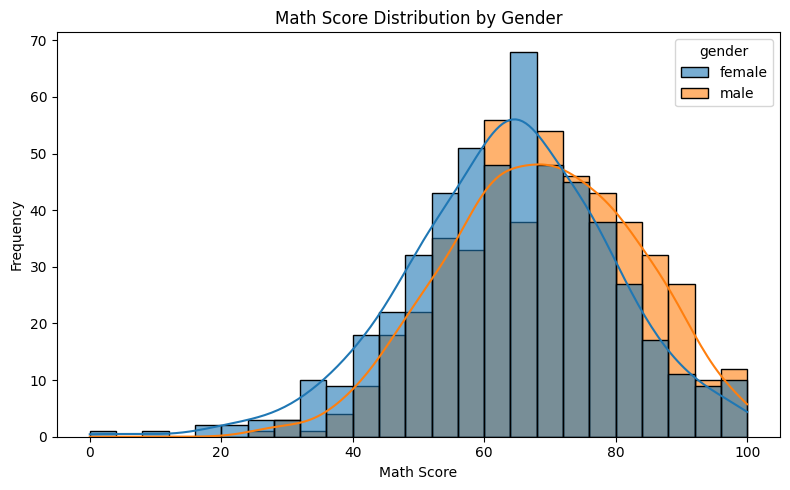

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="math score", hue="gender", kde=True, alpha=0.6)

plt.title("Math Score Distribution by Gender")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../output/chart1_math_hist.png")
plt.show()

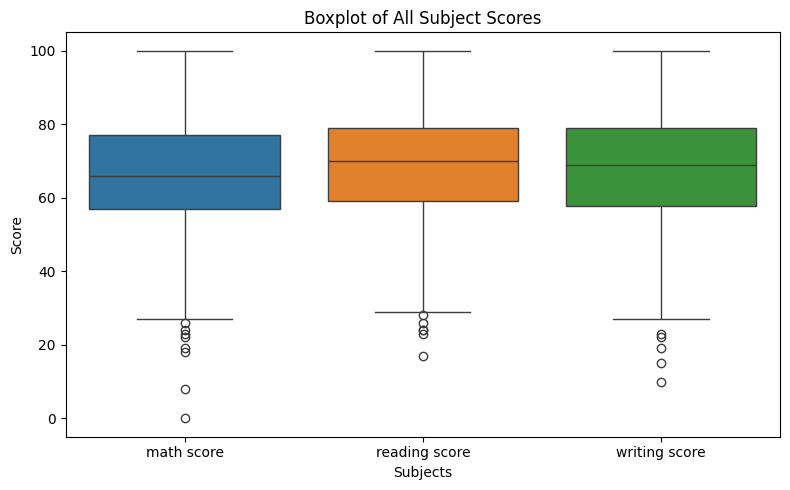

In [37]:
score_cols = ["math score", "reading score", "writing score"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df[score_cols])

plt.title("Boxplot of All Subject Scores")
plt.xlabel("Subjects")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig("../output/chart2_boxplot.png")
plt.show()

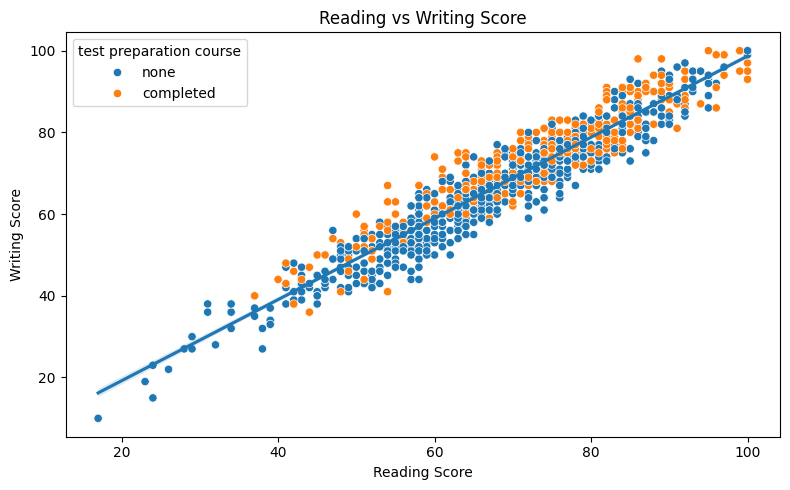

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="reading score", y="writing score", hue="test preparation course")
sns.regplot(data=df, x="reading score", y="writing score", scatter=False)

plt.title("Reading vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.tight_layout()
plt.savefig("../output/chart3_scatter.png")
plt.show()

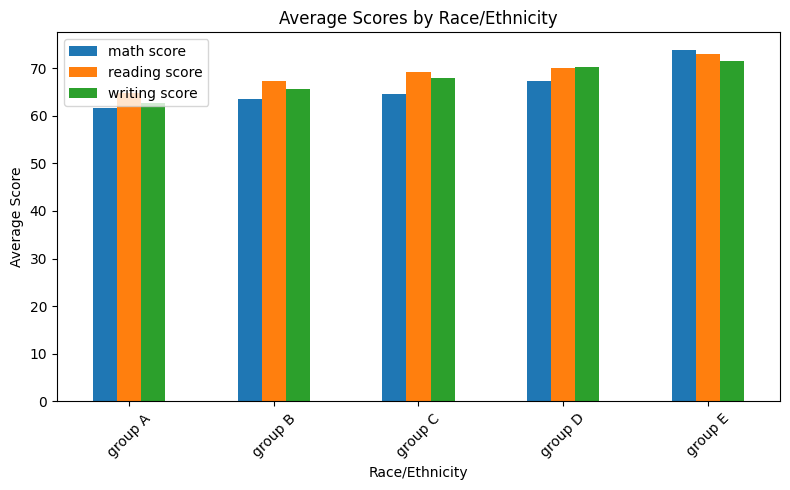

In [39]:
race_scores = df.groupby("race/ethnicity")[score_cols].mean()

race_scores.plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Race/Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../output/chart4_race_bar.png")
plt.show()

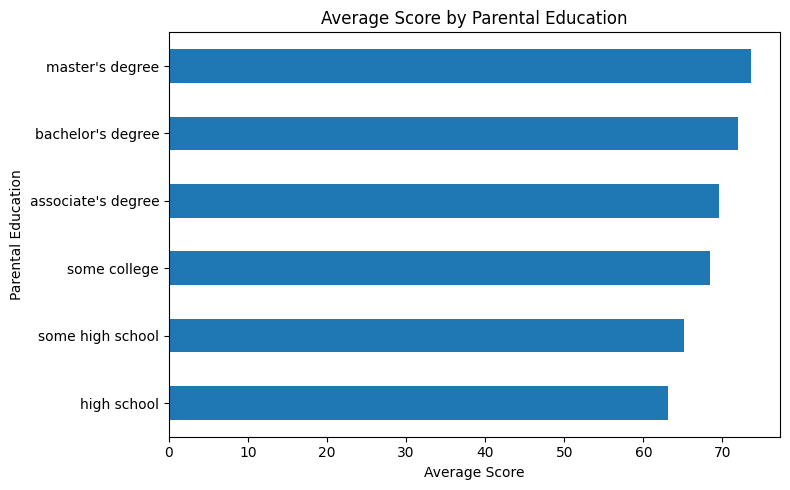

In [40]:
parent_avg = df.groupby("parental level of education")["average_score"].mean().sort_values()

parent_avg.plot(kind="barh", figsize=(8,5))

plt.title("Average Score by Parental Education")
plt.xlabel("Average Score")
plt.ylabel("Parental Education")

plt.tight_layout()
plt.savefig("../output/chart5_parent_bar.png")
plt.show()

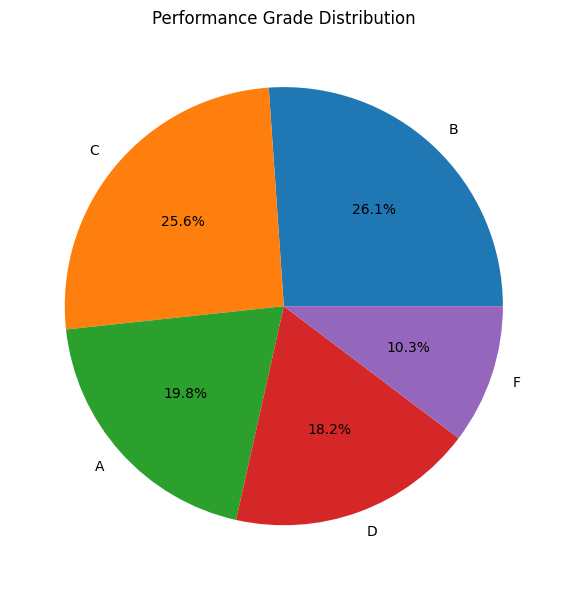

In [41]:
grade_counts = df["performance_grade"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(grade_counts, labels=grade_counts.index, autopct="%1.1f%%")
plt.title("Performance Grade Distribution")

plt.tight_layout()
plt.savefig("../output/chart6_pie.png")
plt.show()

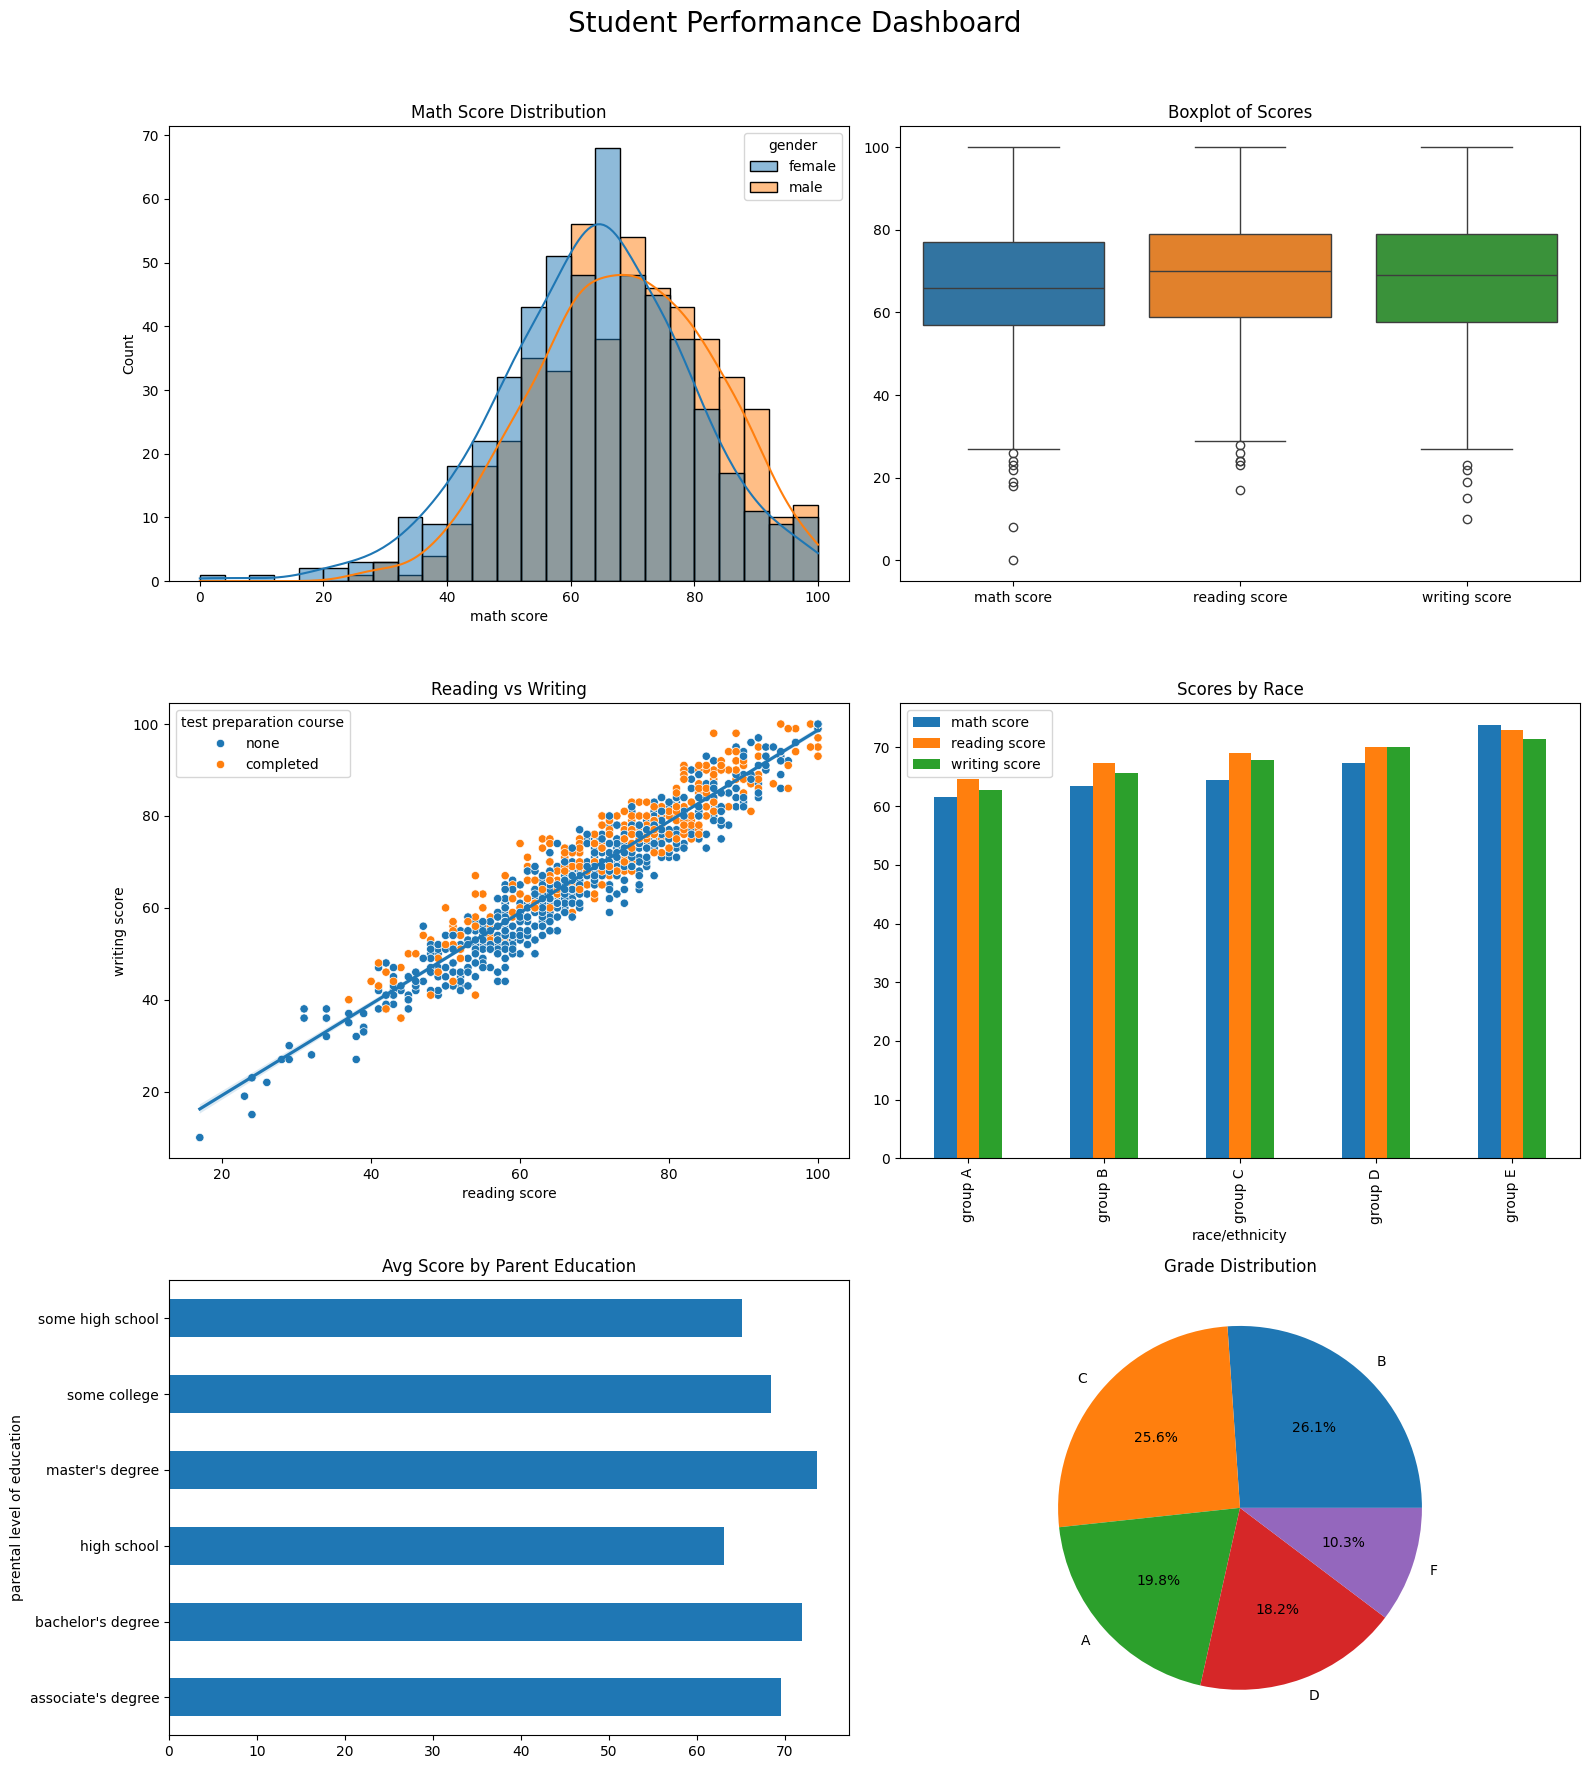

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

score_cols = ["math score", "reading score", "writing score"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Student Performance Dashboard", fontsize=20)

# 1. Histogram
sns.histplot(data=df, x="math score", hue="gender", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Math Score Distribution")

# 2. Boxplot
sns.boxplot(data=df[score_cols], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Scores")

# 3. Scatter + regression
sns.scatterplot(data=df, x="reading score", y="writing score",
                hue="test preparation course", ax=axes[1, 0])

sns.regplot(data=df, x="reading score", y="writing score",
            scatter=False, ax=axes[1, 0])

axes[1, 0].set_title("Reading vs Writing")

# 4. Race bar chart
race_scores = df.groupby("race/ethnicity")[score_cols].mean()
race_scores.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Scores by Race")

# 5. Parent education
parent_avg = df.groupby("parental level of education")["average_score"].mean()
parent_avg.plot(kind="barh", ax=axes[2, 0])
axes[2, 0].set_title("Avg Score by Parent Education")

# 6. Pie chart
grade_counts = df["performance_grade"].value_counts()
axes[2, 1].pie(grade_counts, labels=grade_counts.index, autopct="%1.1f%%")
axes[2, 1].set_title("Grade Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.96])

# IMPORTANT: SAVE AFTER PLOTTING
plt.savefig("../output/eda_dashboard.png", dpi=150)

plt.show()

**Analysis**

Each chart provides a different perspective on student performance. The histogram shows distribution differences between genders. The boxplot highlights spread and outliers. The scatter plot shows a strong relationship between reading and writing scores.

Bar charts reveal group-level differences based on race and parental education. The pie chart summarizes grade distribution. Breaking charts into separate cells improves clarity and makes interpretation easier.